<a href="https://colab.research.google.com/github/Givi-Modebadze/ML_Final_Project/blob/main/experiments/DLinear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

FOLDERNAME = 'ML_Final_Project/walmart-recruiting-store-sales-forecasting'
assert FOLDERNAME is not None, "[!] Enter the foldername."

import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

%cd /content/drive/My\ Drive/$FOLDERNAME/

Mounted at /content/drive
/content/drive/My Drive/ML_Final_Project/walmart-recruiting-store-sales-forecasting


In [2]:
import torch # Main PyTorch Library
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
import torchvision.transforms as transforms # Transform function used to modify and preprocess all the images
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory

device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cuda


# Merge data

In [3]:
df = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
stores = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv')

def merger(df, stores, features):
    df = df.merge(stores, how='left', on='Store')
    df = df.merge(features, how='left', on=['Store', 'Date', 'IsHoliday'])
    return df

df = merger(df, stores, features)
test = merger(test, stores, features)

df.sort_values('Date', inplace=True)
test.sort_values('Date', inplace=True)

y = df['Weekly_Sales']
X = df.drop(columns=['Weekly_Sales'])
dates = df['Date']

# Preprocessor

In [4]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class Preprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.type_encoder = None

    def fit(self, X: pd.DataFrame, y=None):
        if 'Type' in X.columns:
            self.type_encoder = X['Type'].astype('category').cat.categories
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()

        if self.type_encoder is not None:
            X['Type'] = pd.Categorical(X['Type'], categories=self.type_encoder)
            X['Type'] = X['Type'].cat.codes

        if 'IsHoliday' in X.columns:
            X['IsHoliday'] = X['IsHoliday'].astype(int)

        X = X.fillna(0)

        X = X.drop(columns=['Date'], errors='ignore')

        return X

In [5]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_drop=None):
        self.columns_to_drop = columns_to_drop or []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        return X.drop(columns=self.columns_to_drop, errors='ignore')

In [6]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.holidays = {
            'IsSuperBowl': ['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08'],
            'IsLaborDay': ['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06'],
            'IsThanksgiving': ['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29'],
            'IsChristmas': ['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27']
        }

    def fit(self, X, y=None):
        X = X.copy()
        X['Date'] = pd.to_datetime(X['Date'])
        X['Weekly_Sales'] = y.values
        X['Year'] = X['Date'].dt.year
        X['Week'] = X['Date'].dt.isocalendar().week.astype(int)
        self.full_data_ = X[['Store', 'Dept', 'Date', 'Year', 'Week', 'Weekly_Sales']].copy()
        return self

    def transform(self, X):
        X = X.copy()
        X['Date'] = pd.to_datetime(X['Date'])
        X['Year'] = X['Date'].dt.year
        X['Month'] = X['Date'].dt.month
        X['Week'] = X['Date'].dt.isocalendar().week.astype(int)
        X['Day'] = X['Date'].dt.day
        X['DayOfWeek'] = X['Date'].dt.dayofweek

        for holiday_name, date_list in self.holidays.items():
            holiday_dates = pd.to_datetime(date_list)
            X[holiday_name] = X['Date'].isin(holiday_dates).astype(int)

        base = self.full_data_.copy()
        last_year = base.copy()
        last_year['Year'] += 1
        last_year = last_year.rename(columns={'Weekly_Sales': 'Sales_LastYear'})

        df = X.merge(
            last_year[['Store', 'Dept', 'Year', 'Week', 'Sales_LastYear']],
            on=['Store', 'Dept', 'Year', 'Week'],
            how='left'
        )

        two_years_ago = base.copy()
        two_years_ago['Year'] += 2
        two_years_ago = two_years_ago.rename(columns={'Weekly_Sales': 'Sales_TwoYearsAgo'})

        df = df.merge(
            two_years_ago[['Store', 'Dept', 'Year', 'Week', 'Sales_TwoYearsAgo']],
            on=['Store', 'Dept', 'Year', 'Week'],
            how='left'
        )

        df['PrevYearSales'] = df['Sales_LastYear'].fillna(df['Sales_TwoYearsAgo'])
        df.drop(columns=['Sales_LastYear', 'Sales_TwoYearsAgo'], inplace=True)

        return df

# cross validation

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

def weighted_mae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

def cross_validation(pipeline, X, y, df_with_dates):
    from matplotlib.dates import DateFormatter

    tscv = TimeSeriesSplit(n_splits=8)
    rmse_scores = []
    wmae_scores = []
    train_rmse_scores = []
    train_wmae_scores = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        if fold < 4:
          continue

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipeline.fit(X_train, y_train)

        y_val_pred = pipeline.predict(X_val)
        y_train_pred = pipeline.predict(X_train)

        val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

        val_is_holiday = df_with_dates.iloc[val_idx]['IsHoliday'].astype(int)
        train_is_holiday = df_with_dates.iloc[train_idx]['IsHoliday'].astype(int)

        val_wmae = weighted_mae(y_val, y_val_pred, val_is_holiday)
        train_wmae = weighted_mae(y_train, y_train_pred, train_is_holiday)

        print(f"\nFold {fold + 1} Scores:")
        print(f"Train RMSE: {train_rmse:.2f} | Train WMAE: {train_wmae:.2f}")
        print(f"Valid RMSE: {val_rmse:.2f} | Valid WMAE: {val_wmae:.2f}")

        rmse_scores.append(val_rmse)
        wmae_scores.append(val_wmae)
        train_rmse_scores.append(train_rmse)
        train_wmae_scores.append(train_wmae)

        df_all = pd.DataFrame({
            'Date': pd.to_datetime(df_with_dates['Date']),
            'y': y.values
        })
        df_all = df_all.groupby('Date').sum().reset_index().sort_values('Date')

        df_val = pd.DataFrame({
            'Date': pd.to_datetime(df_with_dates.iloc[val_idx]['Date']),
            'Actual': y_val.values,
            'Predicted': y_val_pred
        }).groupby('Date').sum().reset_index().sort_values('Date')

        df_train = pd.DataFrame({
            'Date': pd.to_datetime(df_with_dates.iloc[train_idx]['Date']),
            'Actual': y_train.values,
            'Predicted': y_train_pred
        }).groupby('Date').sum().reset_index().sort_values('Date')

        plt.figure(figsize=(12, 4))

        plt.plot(df_all['Date'], df_all['y'], color='gray', label='Train Actuals', linewidth=1.5, alpha=0.4)

        plt.plot(df_train['Date'], df_train['Predicted'], color='green', label='Train Predicted', linewidth=1.5, alpha=0.8)

        plt.plot(df_val['Date'], df_val['Actual'], color='blue', label='Val Actuals', linewidth=2)

        plt.plot(df_val['Date'], df_val['Predicted'], color='orange', label='Val Predicted', linewidth=2)

        plt.title(f'Fold {fold + 1} - Weekly Sales Over Time', fontsize=14)
        plt.xlabel("Date")
        plt.ylabel("Weekly Sales")
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    print(f"\nMean Train RMSE: {np.mean(train_rmse_scores):.2f}")
    print(f"Mean Train WMAE: {np.mean(train_wmae_scores):.2f}")
    print(f"Mean Valid RMSE: {np.mean(rmse_scores):.2f}")
    print(f"Mean Valid WMAE: {np.mean(wmae_scores):.2f}")

# Pipeline

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.preprocessing import StandardScaler
import numpy as np

class DLinearRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, seq_len=52, kernel_size=25):
        self.seq_len = seq_len
        self.kernel_size = kernel_size
        self.trend_model = LinearRegression()
        self.seasonal_model = LinearRegression()
        self.scaler = StandardScaler()

    def _moving_average(self, data, window):
        return np.convolve(data, np.ones(window)/window, mode='same')

    def _decompose(self, y):
        trend = self._moving_average(y, self.kernel_size)
        seasonal = y - trend
        return trend, seasonal

    def fit(self, X, y):
        X_scaled = self.scaler.fit_transform(X)
        trend, seasonal = self._decompose(y)

        self.trend_model.fit(X_scaled, trend)
        self.seasonal_model.fit(X_scaled, seasonal)

        return self

    def predict(self, X):
        X_scaled = self.scaler.transform(X)
        trend_pred = self.trend_model.predict(X_scaled)
        seasonal_pred = self.seasonal_model.predict(X_scaled)
        return trend_pred + seasonal_pred

/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(



Fold 5 Scores:
Train RMSE: 18325.73 | Train WMAE: 11599.98
Valid RMSE: 8181.70 | Valid WMAE: 7334.15


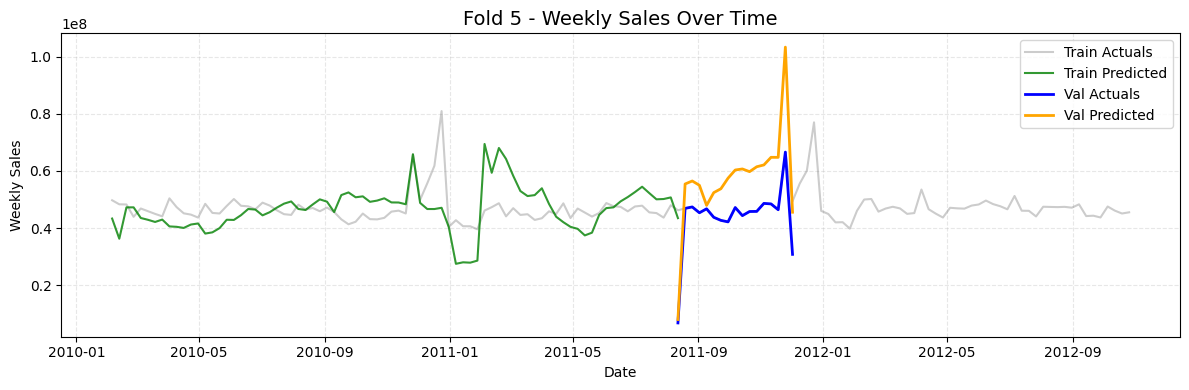

/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(



Fold 6 Scores:
Train RMSE: 16941.88 | Train WMAE: 10116.86
Valid RMSE: 6900.25 | Valid WMAE: 5317.88


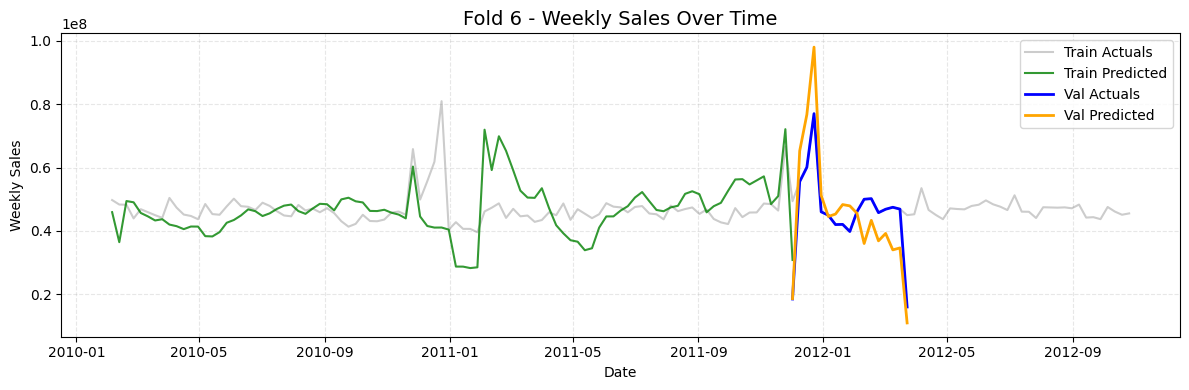

/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(



Fold 7 Scores:
Train RMSE: 15878.77 | Train WMAE: 9157.16
Valid RMSE: 6984.61 | Valid WMAE: 5037.48


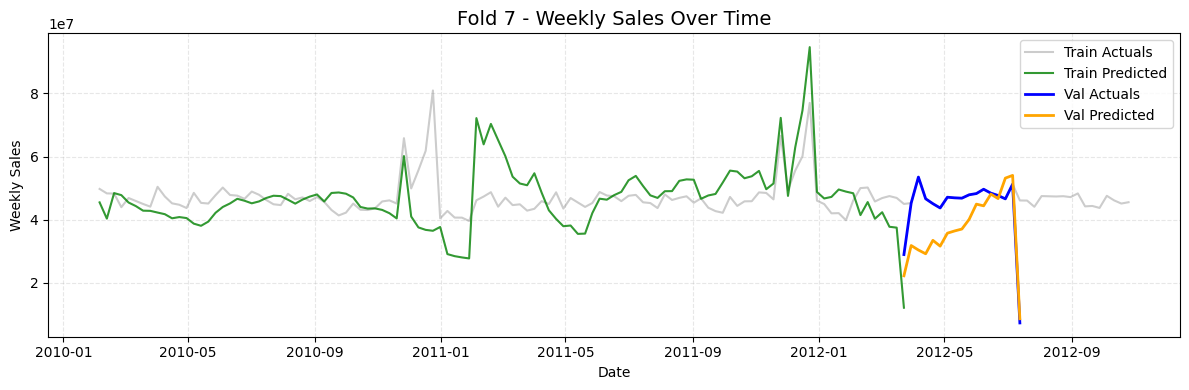

/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(



Fold 8 Scores:
Train RMSE: 15032.93 | Train WMAE: 8616.18
Valid RMSE: 5336.49 | Valid WMAE: 3964.98


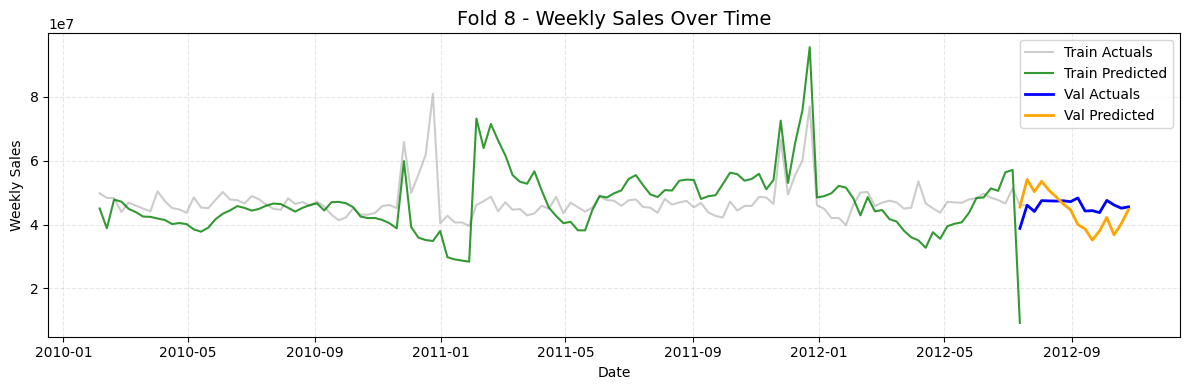


Mean Train RMSE: 16544.83
Mean Train WMAE: 9872.55
Mean Valid RMSE: 6850.76
Mean Valid WMAE: 5413.62


In [18]:
from sklearn.pipeline import Pipeline

preprocessor = Preprocessor()
feature_selection = FeatureSelector(columns_to_drop=['IsHoliday','Year','Month','Date'])
feature_engineer = FeatureEngineer()
model = DLinearRegressor(
    seq_len=52,
    kernel_size=10
)

pipeline = Pipeline([
    ('feature_engineer', feature_engineer),
    ('preprocessor', preprocessor),
    ('feature selection', feature_selection),
    ('model', model)
])

cross_validation(pipeline, X, y, df)

In [19]:
pipeline.fit(X, y)

Pipeline(steps=[('feature_engineer', FeatureEngineer()),
                ('preprocessor', Preprocessor()),
                ('feature selection',
                 FeatureSelector(columns_to_drop=['IsHoliday', 'Year', 'Month',
                                                  'Date'])),
                ('model', DLinearRegressor(kernel_size=10))])

In [12]:
!pip install dagshub
!pip install "mlflow<3"

import mlflow
import dagshub

dagshub.init(repo_owner='gbend22', repo_name='ML_Final_Project', mlflow=True)

experiment = "Final Project DLinear"
mlflow.set_experiment(experiment)

  Using cached dagshub-0.5.10-py3-none-any.whl.metadata (12 kB)
  Using cached appdirs-1.4.4-py2.py3-none-any.whl.metadata (9.0 kB)
  Using cached dacite-1.6.0-py3-none-any.whl.metadata (14 kB)
  Using cached gql-3.5.3-py2.py3-none-any.whl.metadata (9.4 kB)
  Using cached dataclasses_json-0.6.7-py3-none-any.whl.metadata (25 kB)
  Using cached treelib-1.8.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached pathvalidate-3.3.1-py3-none-any.whl.metadata (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.0/261.0 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.9/13.9 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 4.0

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=5e58af4f-5db7-437a-a3e5-9bbf6aa7a986&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=a6eb40a1e0d16ef585690822c2270cc5eaa339baabe85c79ae86214bcb0beae9




Accessing as gbend22

Initialized MLflow to track repo "gbend22/ML_Final_Project"

Repository gbend22/ML_Final_Project initialized!

2025/07/17 11:27:56 INFO mlflow.tracking.fluent: Experiment with name 'Final Project DLinear' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/fad32ed863e442768da79fb2273f1f3a', creation_time=1752751675978, experiment_id='6', last_update_time=1752751675978, lifecycle_stage='active', name='Final Project DLinear', tags={}>

In [20]:
with mlflow.start_run(run_name="smaller_kernel_size") as run:
    mlflow.sklearn.log_model(
        sk_model=pipeline,
        artifact_path="DLinear_pipeline_model",
        registered_model_name="DLinearPipelineModel"
    )

    mlflow.log_params({
        'seq_len': 52,
        'kernel_size': 10,
    })

    mlflow.log_metrics({
        "Mean Train RMSE" : 16544.83,
        "Mean Train WMAE" : 9872.55,
        "Mean Valid RMSE" : 6850.76,
        "Mean Valid WMAE" : 5413.62,
    })

2025/07/17 11:32:49 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'DLinearPipelineModel' already exists. Creating a new version of this model...
2025/07/17 11:32:57 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: DLinearPipelineModel, version 2
Created version '2' of model 'DLinearPipelineModel'.


🏃 View run smaller_kernel_size at: https://dagshub.com/gbend22/ML_Final_Project.mlflow/#/experiments/6/runs/aec88b1d947f488db1781d5510d6e569
🧪 View experiment at: https://dagshub.com/gbend22/ML_Final_Project.mlflow/#/experiments/6
